<a href="https://colab.research.google.com/github/zeynepuygrr/softito_hw/blob/main/22_09_2026odev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import statsmodels.api as sm

sns.set_style("whitegrid")
sns.set_context("poster")
import warnings
warnings.filterwarnings("ignore")
#

In [ ]:
column_names = [
    "Sex",             # Kategorik: M, F, I
    "Length",          # Sayısal (float)
    "Diameter",        # Sayısal (float)
    "Height",          # Sayısal (float)
    "Whole_weight",    # Sayısal (float)
    "Shucked_weight",  # Sayısal (float)
    "Viscera_weight",  # Sayısal (float)
    "Shell_weight",    # Sayısal (float)
    "Rings"            # Hedef değişken (int) - tahmin edeceğimiz değer
]
df= pd.read_csv("abalone.data",header=None,names=column_names)
df["Age"] = df["Rings"]+1.5
df.head(2)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Age
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.15,15,16.5
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.07,7,8.5


In [ ]:
print("Veri Seti Boyutu:",df.shape)
df.info()

Veri Seti Boyutu: (4177, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
 9   Age             4177 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 326.5+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole_weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked_weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera_weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell_weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000
Age,4177.0,11.433684,3.224169,2.5000,9.5000,10.5000,12.500,30.5000


In [ ]:
df["Sex"].value_counts()

,count
Sex,
M,1528
I,1342
F,1307


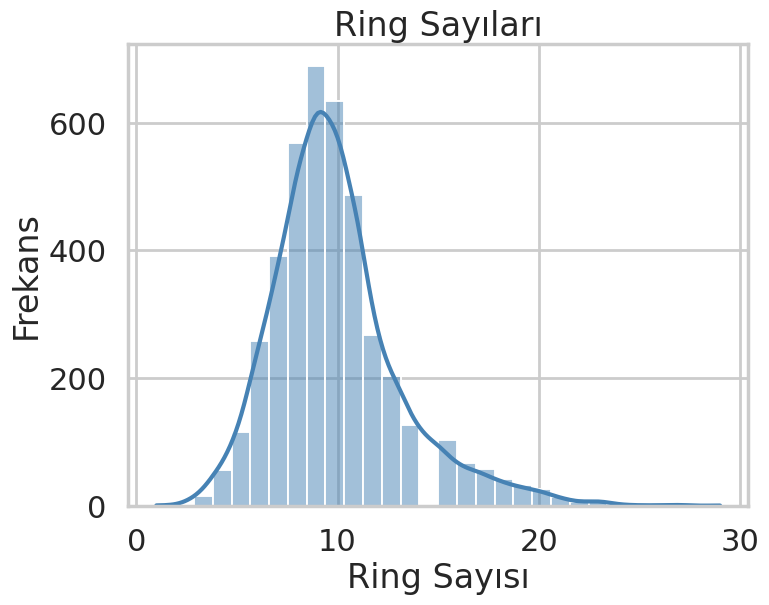

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df["Rings"],bins=30,kde= True, color ="steelblue")

plt.title("Ring Sayıları")
plt.xlabel("Ring Sayısı")
plt.ylabel("Frekans")

plt.show()

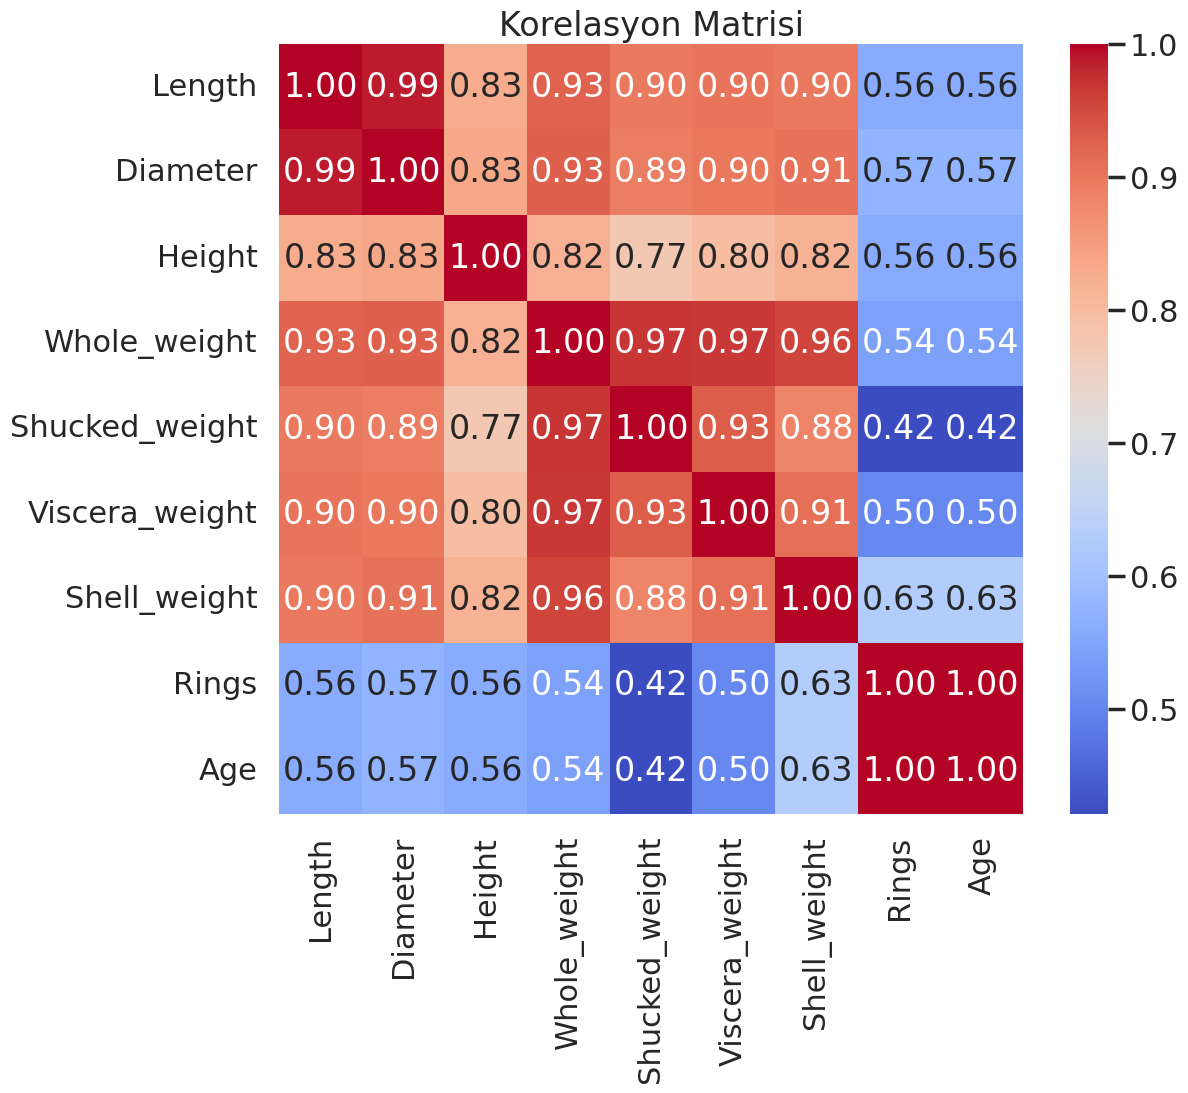

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]) # numeric_cols = df.drop(columns=["X"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12, 10
                    ))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, columns=["Sex"],drop_first=True)
df_encoded["Sex_I"] =df_encoded["Sex_I"].astype(int)
df_encoded["Sex_M"] =df_encoded["Sex_M"].astype(int)

In [ ]:
df_encoded

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Age,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,16.5,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,8.5,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,10.5,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,11.5,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,8.5,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,12.5,0,0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,11.5,0,1
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,10.5,0,1
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,11.5,0,0


In [ ]:
X= df_encoded.drop(columns=["Rings","Age"])
y= df_encoded["Rings"]

In [ ]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)
model_pred =model.predict(X_test)


In [ ]:
r2_multi = r2_score(y_test,model_pred)
print("R2 Değeri:",r2_multi)
mae_multi = mean_absolute_error(y_test,model_pred)
print("MAE Değeri:",mae_multi)
mse_multi = mean_squared_error(y_test,model_pred)
print("MSE Değeri:",mse_multi)

R2 Değeri: 0.5481628137889265
MAE Değeri: 1.5931067816608353
MSE Değeri: 4.891232447128576


In [ ]:
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train,X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Rings   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     425.5
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:42:16   Log-Likelihood:                -7355.4
No. Observations:                3341   AIC:                         1.473e+04
Df Residuals:                    3331   BIC:                         1.479e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.7435      0.330     11.333      0.000       3.096       4.391
Length            -0.2016      2.080     -0.097      0.923      -4.281       3.877
Diameter          11.1234      2.547      4.367      0.000       6.130      16.117
Height            10.4453      1.615      6.467      0.000       7.278      13.612
Whole_weight       8.9322      0.863     10.346      0.000       7.239      10.625
Shucked_weight   -20.2565      0.967    -20.943      0.000     -22.153     -18.360
Viscera_weight    -9.5589      1.470     -6.504      0.000     -12.441      -6.677
Shell_weight       8.7924      1.308      6.724      0.000       6.228      11.356
Sex_I             -0.7190      0.114     -6.319      0.000      -0.942      -0.496
Sex_M              0.1033      0.093      1.108      0.268      -0.080       0.286
==============================================================================
Omnibus:                      750.514   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2218.560
Skew:                           1.155   Prob(JB):                         0.00
Kurtosis:                       6.256   Cond. No.                         141.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Tahmin Edilen Değerler')

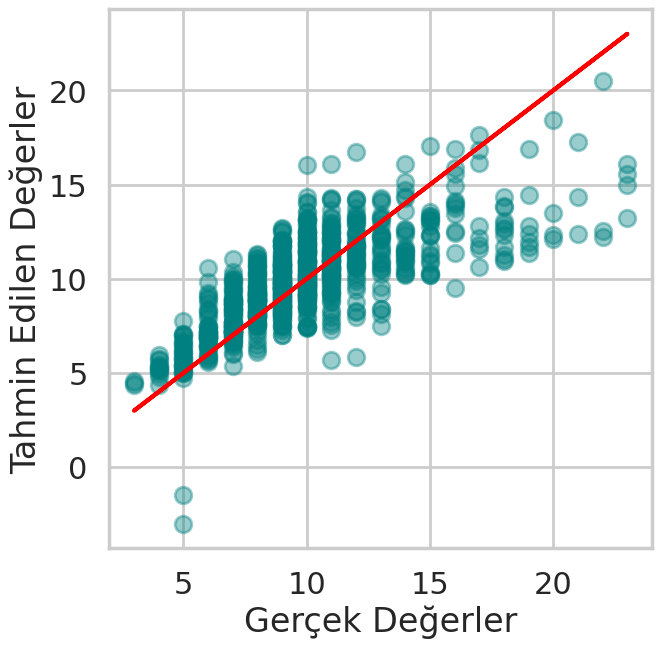

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,model_pred ,alpha=0.4,color="teal")
plt.plot(y_test,y_test,"r")
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")

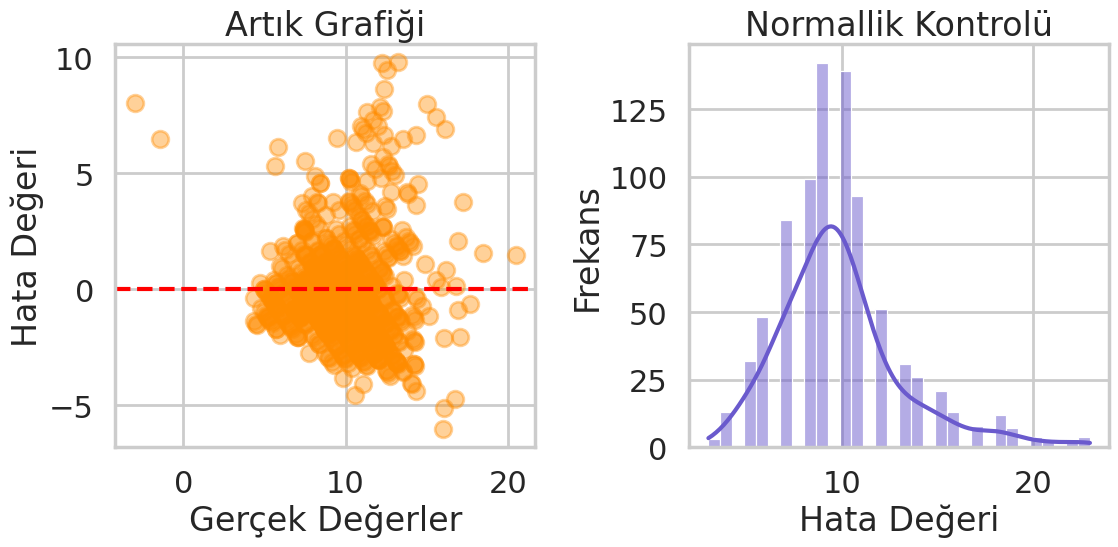

In [ ]:
residual =y_test-model_pred
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].scatter(model_pred,residual,alpha=0.4,color="darkorange")
axes[0].axhline(y=0,color="red",linestyle="--")
axes[0].set_xlabel("Gerçek Değerler")
axes[0].set_ylabel("Hata Değeri")
axes[0].set_title("Artık Grafiği")
sns.histplot(y_test,kde=True,ax=axes[1],color="slateblue")
axes[1].set_title("Gerçek Değerler")
axes[1].set_title("Normallik Kontrolü")
axes[1].set_xlabel("Hata Değeri")
axes[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()


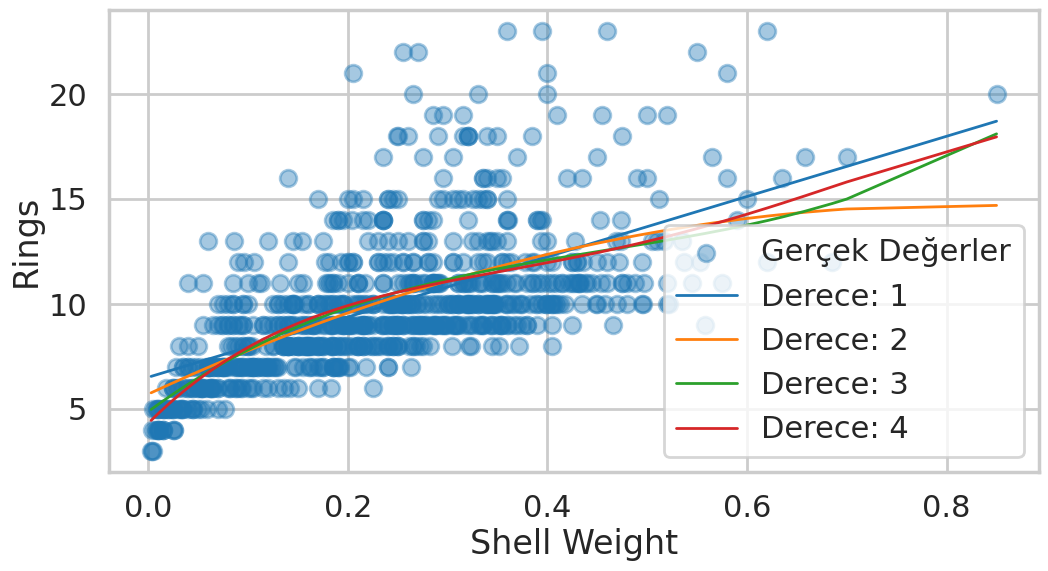

,r2,Rmse
Derece,,
1,0.400853,2.546741
2,0.414645,2.517259
3,0.426366,2.491928
4,0.429181,2.485808


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degress =[1,2,3,4]

poly_results= {}

plt.figure(figsize=(12,6))
X_one_train =X_train[['Shell_weight']]
X_one_test =X_test[['Shell_weight']]
sort_idx =X_one_test['Shell_weight'].values.argsort()
x_sorted =X_one_test['Shell_weight'].values[sort_idx]
plt.scatter(X_one_test['Shell_weight'],y_test,alpha=0.4,color="#1f77b4",label="Gerçek Değerler")
for degree in degress:
    model_poly = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model_poly.fit(X_one_train,y_train)
    poly_pred = model_poly.predict(X_one_test)
    poly_results[degree]={
        "r2": r2_score(y_test,poly_pred),
        "Rmse" : np.sqrt(mean_squared_error(y_test,poly_pred))
}
    y_line = model_poly.predict(x_sorted.reshape(-1,1))
    plt.plot(x_sorted,y_line,linewidth=2,label=f"Derece: {degree}")
plt.xlabel("Shell Weight")
plt.ylabel("Rings")
plt.legend()
plt.show()

pd.DataFrame(poly_results).T.rename_axis("Derece")


In [ ]:
poly_features = PolynomialFeatures(degree=2)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_multi_model =LinearRegression()
poly_multi_model.fit(X_poly_train,y_train)
poly_multi_pred =poly_multi_model.predict(X_poly_test)

r2_score_poly = r2_score(y_test,poly_multi_pred)
print("R2 Değeri:",r2_score_poly)
mae_poly = mean_absolute_error(y_test,poly_multi_pred)
print("MAE Değeri:",mae_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test,poly_multi_pred))
print("RMSE Değeri:",rmse_poly)

R2 Değeri: 0.5538221504793434
MAE Değeri: 1.5384645096330274
RMSE Değeri: 2.1977190308900463


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score,
recall_score,f1_score,classification_report,roc_curve,roc_auc_score)

In [ ]:
column_names = [
    "Checking_account_status",   # A11-A14: mevcut vadesiz hesap durumu
    "Duration_months",           # sayısal: kredi vadesi (ay)
    "Credit_history",            # A30-A34: geçmiş kredi ödeme durumu
    "Purpose",                   # A40-A410: kredinin amacı
    "Credit_amount",             # sayısal: kredi tutarı
    "Savings_account",           # A61-A65: tasarruf hesabı durumu
    "Employment_since",          # A71-A75: mevcut işte çalışma süresi
    "Installment_rate",          # sayısal: taksit oranı (gelire göre %)
    "Personal_status_sex",       # A91-A95: medeni durum ve cinsiyet
    "Other_debtors",             # A101-A103: diğer borçlular/kefiller
    "Present_residence_since",   # sayısal: mevcut ikametgahta kaç yıldır oturuyor
    "Property",                  # A121-A124: sahip olunan mülk türü
    "Age",                       # sayısal: yaş
    "Other_installment_plans",   # A141-A143: diğer taksitli ödeme planları
    "Housing",                   # A151-A153: konut durumu (kira/kendi/bedava)
    "Existing_credits",          # sayısal: bu bankadaki mevcut kredi sayısı
    "Job",                       # A171-A174: meslek/iş durumu
    "People_liable",             # sayısal: bakmakla yükümlü olunan kişi sayısı
    "Telephone",                 # A191-A192: telefon sahipliği
    "Foreign_worker",            # A201-A202: yabancı işçi mi
    "Target"                     # 1 = İyi (Good), 2 = Kötü (Bad) kredi riski
]
df = pd.read_csv("german.data", sep=r"\s+", header=None, names=column_names)

df.head(2)

,Checking_account_status,Duration_months,Credit_history,Purpose,Credit_amount,Savings_account,Employment_since,Installment_rate,Personal_status_sex,Other_debtors,...,Property,Age,Other_installment_plans,Housing,Existing_credits,Job,People_liable,Telephone,Foreign_worker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2


In [ ]:
print("Veri seti boyutu:",df.shape)
df.info()

Veri seti boyutu: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Checking_account_status  1000 non-null   object
 1   Duration_months          1000 non-null   int64 
 2   Credit_history           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_amount            1000 non-null   int64 
 5   Savings_account          1000 non-null   object
 6   Employment_since         1000 non-null   object
 7   Installment_rate         1000 non-null   int64 
 8   Personal_status_sex      1000 non-null   object
 9   Other_debtors            1000 non-null   object
 10  Present_residence_since  1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_installment_plans  1000 non-null   object
 14  Housing     

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Present_residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
People_liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
Target,1000.0,1.300,0.458487,1.0,1.0,1.0,2.00,2.0


In [ ]:
df["Bad_risk"] = (df["Target"]==2).astype(int)
df =df.drop(columns=["Target"])
df["Bad_risk"].value_counts(normalize=True).rename(index={0:"iyi",1:"Kötü"})

,proportion
Bad_risk,
iyi,0.7
Kötü,0.3


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

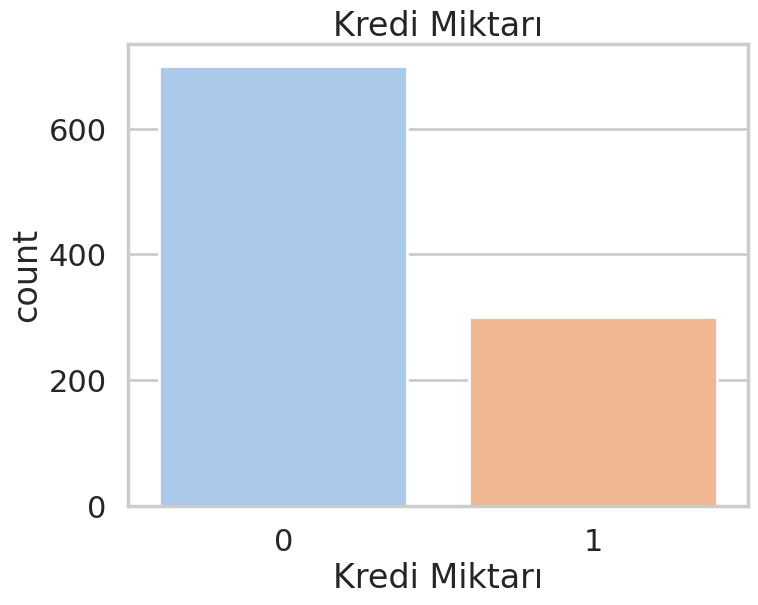

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="Bad_risk",data=df,palette="pastel")

plt.title("Kredi Miktarı")
plt.xlabel("Kredi Miktarı")
plt

<Axes: >

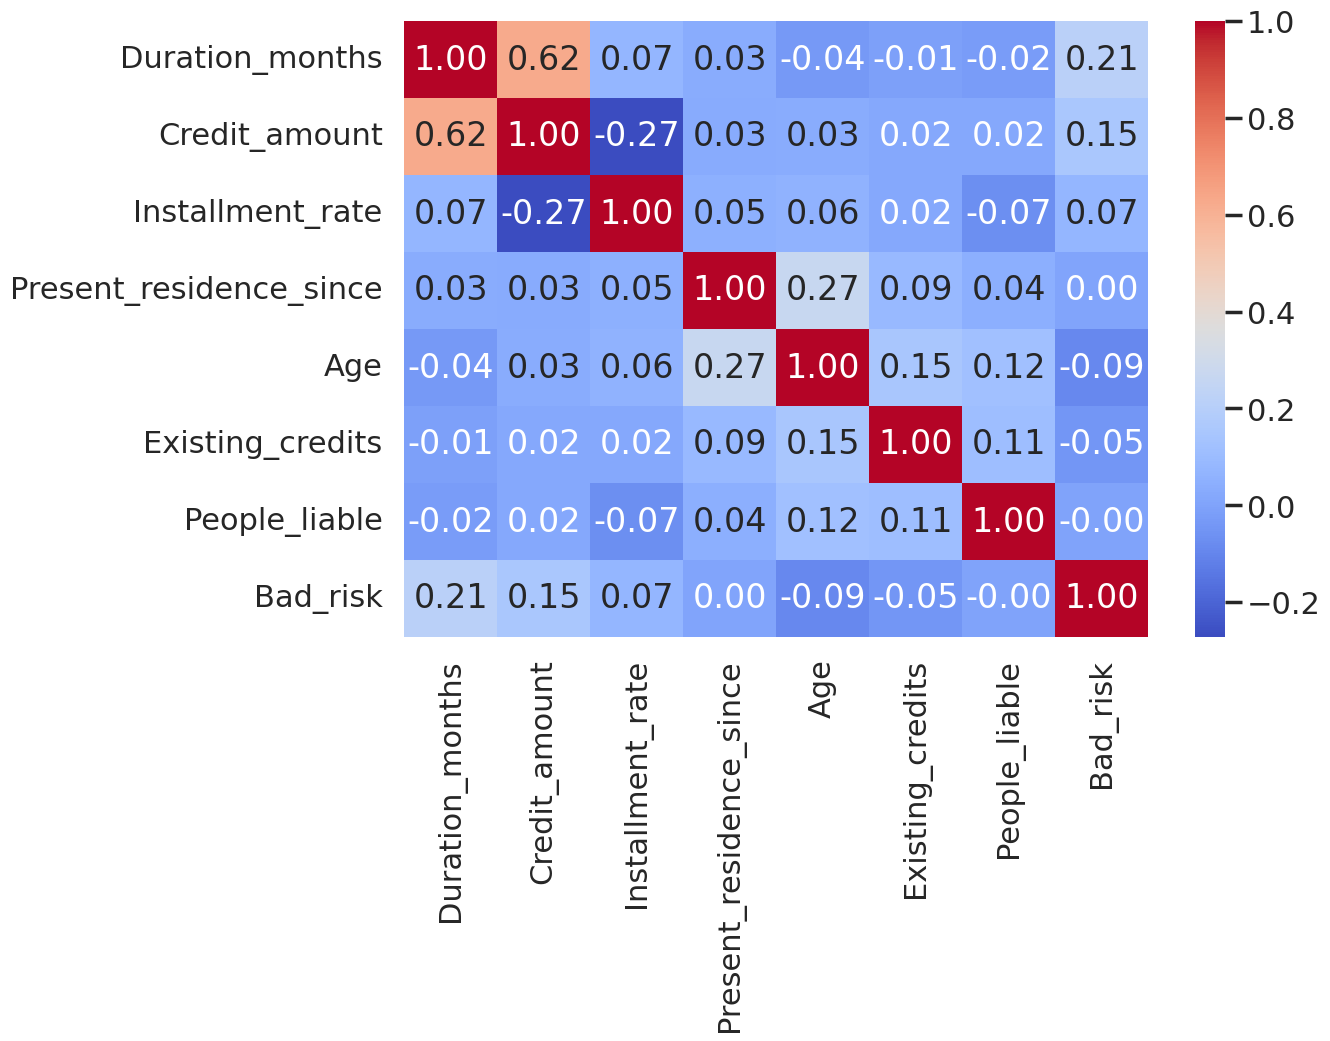

In [ ]:
numeric_cols=df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()



,Duration_months,Credit_amount,Installment_rate,Present_residence_since,Age,Existing_credits,People_liable,Bad_risk,Checking_account_status_A12,Checking_account_status_A13,...,Property_A124,Other_installment_plans_A142,Other_installment_plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_worker_A202
0,6,1169,4,4,67,2,1,0,0,0,...,0,0,1,1,0,0,1,0,1,0
1,48,5951,2,2,22,1,1,1,1,0,...,0,0,1,1,0,0,1,0,0,0
2,12,2096,2,3,49,1,2,0,0,0,...,0,0,1,1,0,1,0,0,0,0
3,42,7882,2,4,45,1,2,0,0,0,...,0,0,1,0,1,0,1,0,0,0
4,24,4870,3,4,53,2,2,1,0,0,...,1,0,1,0,1,0,1,0,0,0


In [ ]:
X=df_encoded.drop(columns=["Bad_risk"])
y=df_encoded["Bad_risk"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)
X_train_scaled.head()

,Duration_months,Credit_amount,Installment_rate,Present_residence_since,Age,Existing_credits,People_liable,Checking_account_status_A12,Checking_account_status_A13,Checking_account_status_A14,...,Property_A124,Other_installment_plans_A142,Other_installment_plans_A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_worker_A202
828,1.289592,1.925766,0.052281,1.053413,1.057784,-0.718745,-0.436436,-0.604308,-0.260942,-0.808018,...,2.334869,-0.226381,0.482354,-1.574249,2.881376,-0.496091,0.752036,-0.409736,-0.82717,-0.200779
997,-0.742595,-0.892853,0.942164,1.053413,0.242449,-0.718745,-0.436436,-0.604308,-0.260942,1.237597,...,-0.428290,-0.226381,0.482354,0.635223,-0.347056,-0.496091,0.752036,-0.409736,-0.82717,-0.200779
148,1.289592,0.816433,0.052281,-0.747293,-0.663479,1.045047,-0.436436,-0.604308,-0.260942,-0.808018,...,-0.428290,-0.226381,0.482354,0.635223,-0.347056,-0.496091,0.752036,-0.409736,-0.82717,-0.200779
735,1.289592,0.299568,0.052281,-0.747293,-0.572886,-0.718745,-0.436436,1.654786,-0.260942,-0.808018,...,2.334869,-0.226381,-2.073165,0.635223,-0.347056,-0.496091,-1.329724,-0.409736,-0.82717,-0.200779
130,2.305686,1.982655,-1.727486,-0.747293,-1.025850,-0.718745,-0.436436,1.654786,-0.260942,-0.808018,...,-0.428290,-0.226381,0.482354,0.635223,-0.347056,-0.496091,0.752036,-0.409736,-0.82717,-0.200779


In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_proba =log_reg.predict_proba(X_test_scaled)[:,1]
y_pred =log_reg.predict(X_test_scaled)

results_preview =pd.DataFrame({
    "Gerçek:": y_test.values[:10],
    "Tahmin:": y_pred[:10],
    "Olasılık:": y_proba[:10].round(2)
})

results_preview


,Gerçek:,Tahmin:,Olasılık:
0,0,0,0.20
1,0,0,0.09
2,1,1,0.63
3,0,0,0.50
4,1,0,0.15
5,0,0,0.10
6,0,0,0.22
7,0,0,0.11
8,0,0,0.50
9,0,0,0.12


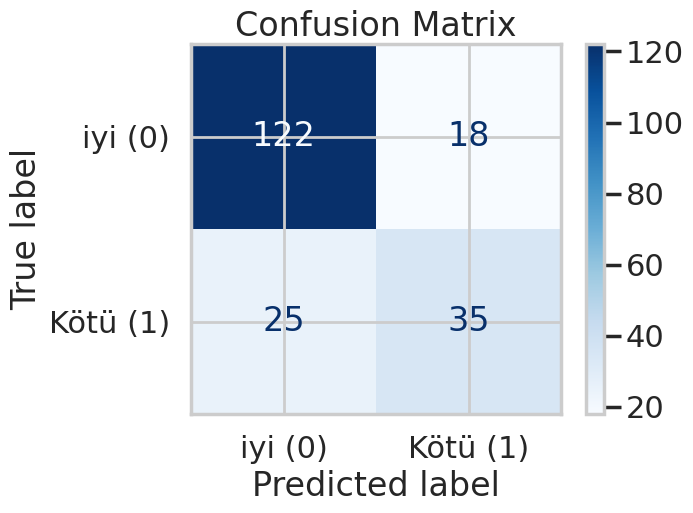

In [ ]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["iyi (0)", "Kötü (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
#

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)


print(classification_report(y_test,y_pred))

Accuracy: 0.785
Precision: 0.660377358490566
Recall: 0.5833333333333334
F1 Score: 0.6194690265486725
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       140
           1       0.66      0.58      0.62        60

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.78      0.79      0.78       200



In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [ ]:
svm_linear = SVC(kernel="linear",C=1.0,probability=True ,random_state=42)
svm_linear.fit(X_train_scaled,y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_proba_linear = svm_linear.predict_proba(X_test_scaled)[:,1]

print(f"toplam destek vektörü sayısı: {svm_linear.n_support_.sum()}")
print(f"support_vectors_: {svm_linear.support_vectors_.shape}")


toplam destek vektörü sayısı: 425
support_vectors_: (425, 48)


In [ ]:
acc_svm = accuracy_score(y_test,y_pred_linear)
prec_svm = precision_score(y_test,y_pred_linear)
rec_svm = recall_score(y_test,y_pred_linear)
f1_svm = f1_score(y_test,y_pred_linear)

print("Accuracy:",acc_svm)
print("Precision:",prec_svm)
print("Recall:",rec_svm)
print("F1 Score:",f1_svm)
print(classification_report(y_test,y_pred_linear))

Accuracy: 0.76
Precision: 0.625
Recall: 0.5
F1 Score: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       140
           1       0.62      0.50      0.56        60

    accuracy                           0.76       200
   macro avg       0.71      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200



In [ ]:
svm_rbf = SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42)
svm_rbf.fit(X_train_scaled,y_train)

SVC(probability=True, random_state=42)

In [ ]:
y_pred_rbf=svm_rbf.predict(X_test_scaled)
y_proba_rbf=svm_rbf.predict_proba(X_test_scaled)[:,1]

In [ ]:
acc_svm_rbf = accuracy_score(y_test,y_pred_rbf)
prec_svm_rbf = precision_score(y_test,y_pred_rbf)
rec_svm_rbf = recall_score(y_test,y_pred_rbf)
f1_svm_rbf = f1_score(y_test,y_pred_rbf)
auc = roc_auc_score(y_test,y_proba_rbf)

In [ ]:
print("Accuracy:",acc_svm_rbf)
print("Precision:",prec_svm_rbf)
print("Recall:",rec_svm_rbf)
print("F1 Score:",f1_svm_rbf)
print("AUC:",auc)

Accuracy: 0.795
Precision: 0.8064516129032258
Recall: 0.4166666666666667
F1 Score: 0.5494505494505495
AUC: 0.7929166666666666


In [ ]:
from sklearn.model_selection import GridSearchCV,cross_val_score

param_grid = {
    "C":[0.1,1,10,100],
    "gamma":[1,0.1,0.01,0.001],
    "kernel":["rbf"]
}

grid_search = GridSearchCV(SVC(probability=True),param_grid,cv=5,scoring="f1",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("En iyi parametreler:",grid_search.best_params_)
print("En iyi skor:",grid_search.best_score_)

En iyi parametreler: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
En iyi skor: 0.5417356213345453


In [ ]:
svm_best = grid_search.best_estimator_

y_pred_best = svm_best.predict(X_test_scaled)
y_proba_best = svm_best.predict_proba(X_test_scaled)[:,1]


acc_svm_best = accuracy_score(y_test,y_pred_best)
prec_svm_best = precision_score(y_test,y_pred_best)
rec_svm_best = recall_score(y_test,y_pred_best)
f1_svm_best = f1_score(y_test,y_pred_best)
auc_svm_best = roc_auc_score(y_test,y_proba_best)


print("Accuracy:",acc_svm_best)
print("Precision:",prec_svm_best)
print("Recall:",rec_svm_best)
print("F1 Score:",f1_svm_best)
print("AUC:",auc_svm_best)

Accuracy: 0.775
Precision: 0.6363636363636364
Recall: 0.5833333333333334
F1 Score: 0.6086956521739131
AUC: 0.803095238095238


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
pca = PCA(n_components=3,random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
np.random.seed(42)
sample_idx =np.random.choice(len(X_train_pca))
sample_point =X_train_pca[sample_idx]

distances = np.sqrt(((X_train_pca-sample_point)**2).sum(axis=1))
k_example=10
nearest_neighbors = distances.argsort()[1:k_example+1]
knn = KNeighborsClassifier(n_neighbors=k_example)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=10)

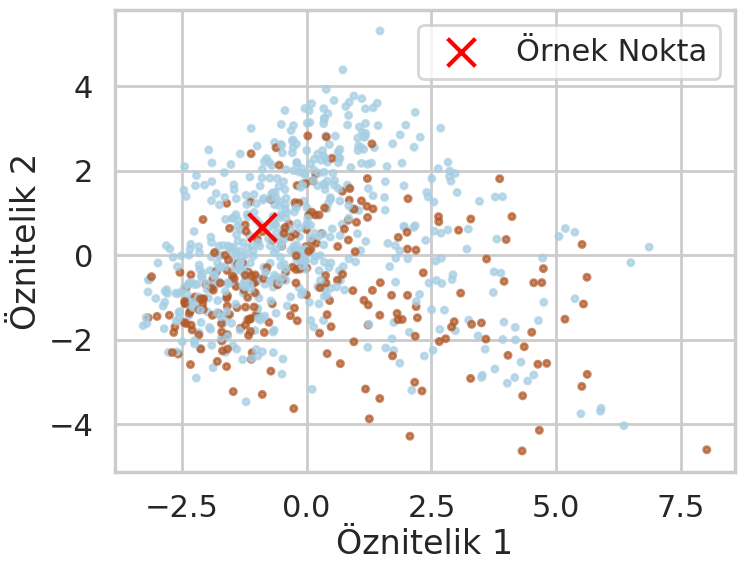

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train,cmap=plt.cm.Paired,alpha=0.70,s=20)
plt.scatter(sample_point[0],sample_point[1],c="red",marker="x",s=400,label="Örnek Nokta")

plt.xlabel("Öznitelik 1")
plt.ylabel("Öznitelik 2")
plt.legend()
plt.show()

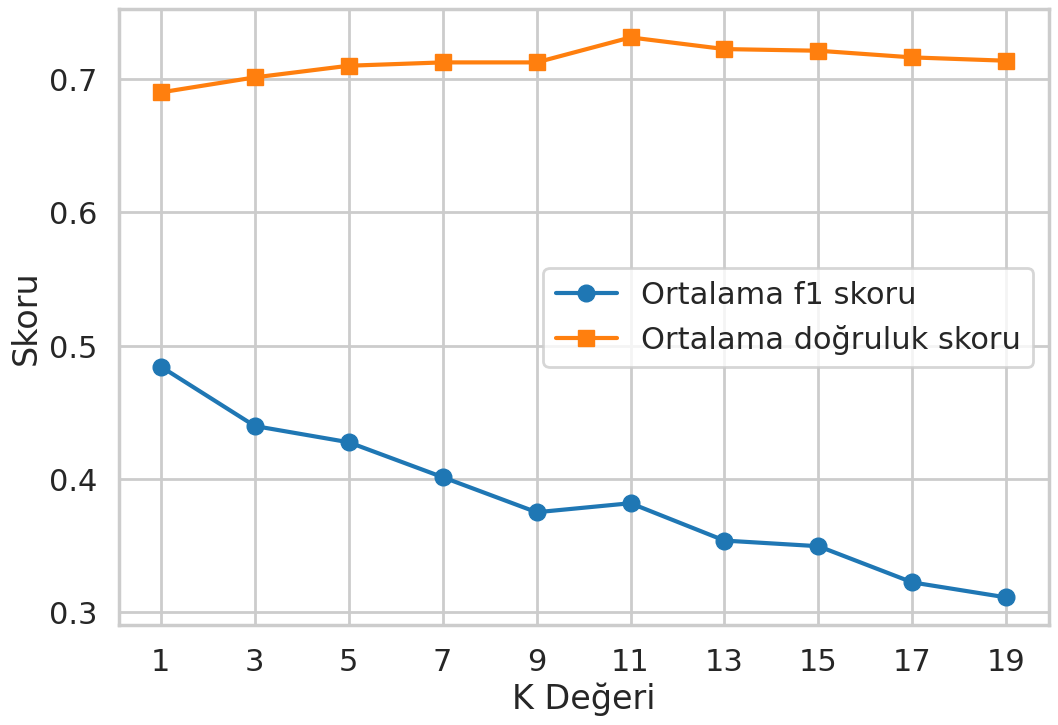

In [ ]:
k_values = list(range(1,21,2))
cv_f1_scores=[]
cv_accuracy_scores=[]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    f1_scores = cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring="f1")
    accuracy_scores = cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring="accuracy")
    cv_f1_scores.append(np.mean(f1_scores))
    cv_accuracy_scores.append(np.mean(accuracy_scores))
plt.figure(figsize=(12,8))
plt.plot(k_values,cv_f1_scores,marker="o",label="Ortalama f1 skoru")
plt.plot(k_values,cv_accuracy_scores,marker="s",label="Ortalama doğruluk skoru")
plt.xlabel("K Değeri")
plt.ylabel("Skoru")
plt.legend()
plt.xticks(k_values)
plt.show()

In [ ]:
param_grid = {
    "n_neighbors":list(range(1,21,2)),
    "weights":["uniform","distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="f1",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("En iyi parametreler:",grid_search.best_params_)
print("En iyi skor:",grid_search.best_score_)

En iyi parametreler: {'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}
En iyi skor: 0.4841848371802289


In [ ]:
knn_best =grid_search.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)
y_proba_knn = knn_best.predict_proba(X_test_scaled)[:,1]

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn)
rec_knn = recall_score(y_test,y_pred_knn)
f1_knn = f1_score(y_test,y_pred_knn)
auc_knn = roc_auc_score(y_test,y_proba_knn)

print("Accuracy:",acc_knn)
print("Precision:",prec_knn)
print("Recall:",rec_knn)
print("F1 Score:",f1_knn)
print("AUC:",auc_knn)
#


Accuracy: 0.635
Precision: 0.4
Recall: 0.43333333333333335
F1 Score: 0.416
AUC: 0.5773809523809524


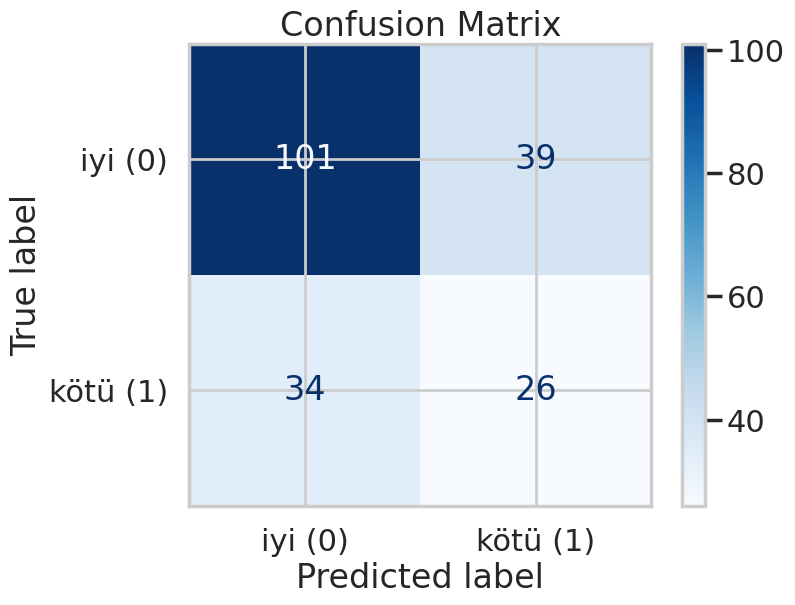

In [ ]:
cm = confusion_matrix(y_test,y_pred_knn)
fig,ax =plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["iyi (0)","kötü (1)"])
disp.plot(ax=ax,cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
#

In [ ]:
# Karşılaştırma için lojistik regresyon ve SVM modellerini de aynı veriyle eğitelim
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm = svm_rbf.predict(X_test_scaled)
y_proba_svm = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# Tüm modellerin metriklerini tek bir tabloda topla
comparison_df = pd.DataFrame({
    "Model": ["Lojistik Regresyon", "SVM (RBF)", f"KNN (k={grid_search.best_params_['n_neighbors']})"],
    "Doğruluk": [
        accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_svm), acc_knn
    ],
    "Kesinlik": [
        precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_svm), prec_knn
    ],
    "Duyarlılık": [
        recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_svm), rec_knn
    ],
    "F1": [
        f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_svm), f1_knn
    ],
    "AUC": [
        roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_svm), auc_knn
    ]
})

comparison_df.round(3)

,Model,Doğruluk,Kesinlik,Duyarlılık,F1,AUC
0,Lojistik Regresyon,0.785,0.660,0.583,0.619,0.800
1,SVM (RBF),0.795,0.806,0.417,0.549,0.793
2,KNN (k=1),0.635,0.400,0.433,0.416,0.577
